In [19]:
# ==========================================
# CELL 1 — LOAD INDIA VIX HISTORICAL DATA
# ==========================================
# IMPORTANT CAVEAT before we start: India VIX is ITSELF computed from NIFTY
# options IV (NSE's official 30-day methodology), similar in spirit to our
# own ATM_IV_30D column. That means predicting TODAY's VIX from TODAY's
# options data would be circular - we'd just be reconstructing a formula,
# not forecasting anything.
#
# The meaningful version of this problem is: predict TOMORROW's (or next
# week's) VIX using only information available TODAY. That's a genuine
# forecasting task, same structure as the realized-vol notebook.

import glob
import os
import numpy as np
import pandas as pd

folder = r"C:\Users\ASUS\Desktop\volPredict"

print("=== LOADING INDIA VIX HISTORY ===")
vix_files = sorted(glob.glob(os.path.join(folder, "hist_india_vix_*.csv")))
print(f"Found {len(vix_files)} VIX files")

vix_list = []
for f in vix_files:
    d = pd.read_csv(f)
    d.columns = d.columns.str.strip()
    vix_list.append(d)

vix = pd.concat(vix_list, ignore_index=True)
vix["Date"] = pd.to_datetime(vix["Date"].str.strip(), format="%d-%b-%Y")
vix = vix.sort_values("Date").drop_duplicates(subset="Date").reset_index(drop=True)
vix = vix.rename(columns={"Close": "VIX_Close", "Open": "VIX_Open", "High": "VIX_High", "Low": "VIX_Low"})
vix = vix[["Date", "VIX_Open", "VIX_High", "VIX_Low", "VIX_Close"]]

print(f"✓ Loaded {len(vix):,} days of India VIX data, {vix['Date'].min().date()} to {vix['Date'].max().date()}")

=== LOADING INDIA VIX HISTORY ===
Found 5 VIX files
✓ Loaded 1,113 days of India VIX data, 2021-01-01 to 2025-06-30


In [20]:
# ==========================================
# CELL 2 — MERGE WITH IV / SMILE FEATURES (SAME AS NOTEBOOK 5)
# ==========================================
print("=== MERGING FEATURE SOURCES ===")

iv_feat = pd.read_csv(os.path.join(folder, "daily_volatility_features.csv"), parse_dates=["Date"])
df = pd.merge(iv_feat, vix, on="Date", how="inner")
print(f"✓ Merged VIX with IV features: {len(df):,} rows")

smile_feat_path = os.path.join(folder, "smile_features.csv")
if os.path.exists(smile_feat_path):
    smile_feat = pd.read_csv(smile_feat_path, parse_dates=["Date"])
    smile_cols_to_use = [
        "Date", "Smile_Level_30D", "Smile_Skew_30D", "Smile_Curv_30D",
        "Smile_Level_14D", "Smile_Skew_14D", "Smile_Curv_14D",
        "Skew_Term_Slope", "Curv_Term_Slope",
    ]
    df = pd.merge(df, smile_feat[smile_cols_to_use], on="Date", how="left")
    HAVE_SMILE_FEATURES = df["Smile_Level_30D"].notna().sum() > 0
    print(f"✓ Merged smile features: {df['Smile_Level_30D'].notna().sum():,} / {len(df):,} rows")
else:
    HAVE_SMILE_FEATURES = False
    print("⚠️ smile_features.csv not found - run notebook 4 first for richer features.")

df = df.sort_values("Date").reset_index(drop=True)
print(df[["Date", "ATM_IV_30D", "VIX_Close"]].tail())

=== MERGING FEATURE SOURCES ===
✓ Merged VIX with IV features: 656 rows
✓ Merged smile features: 656 / 656 rows
          Date  ATM_IV_30D  VIX_Close
651 2025-06-24    0.132375      13.64
652 2025-06-25    0.125095      12.96
653 2025-06-26    0.119896      12.59
654 2025-06-27    0.117079      12.39
655 2025-06-30    0.121933      12.79


In [21]:
# ==========================================
# CELL 3 — DEFINE PREDICTION TARGETS
# ==========================================
# Two horizons: next trading day, and 5 trading days ahead (roughly a week).
# Both targets are FUTURE VIX values - only usable for evaluating a forecast,
# never as an input feature.

print("=== BUILDING PREDICTION TARGETS ===")

df["VIX_next1d"] = df["VIX_Close"].shift(-1)
df["VIX_next5d"] = df["VIX_Close"].shift(-5)

# Also express the change (not just level) - often easier to model, and
# directly shows whether the model is adding anything beyond "stays flat".
df["VIX_chg_next1d"] = df["VIX_next1d"] - df["VIX_Close"]
df["VIX_chg_next5d"] = df["VIX_next5d"] - df["VIX_Close"]

print("✓ Targets built: VIX_next1d, VIX_next5d (levels) and their _chg variants")
print(df[["Date", "VIX_Close", "VIX_next1d", "VIX_next5d"]].tail(8))

=== BUILDING PREDICTION TARGETS ===
✓ Targets built: VIX_next1d, VIX_next5d (levels) and their _chg variants
          Date  VIX_Close  VIX_next1d  VIX_next5d
648 2025-06-19      14.26       13.67       12.59
649 2025-06-20      13.67       14.05       12.39
650 2025-06-23      14.05       13.64       12.79
651 2025-06-24      13.64       12.96         NaN
652 2025-06-25      12.96       12.59         NaN
653 2025-06-26      12.59       12.39         NaN
654 2025-06-27      12.39       12.79         NaN
655 2025-06-30      12.79         NaN         NaN


In [22]:
# ==========================================
# CELL 4 — FEATURE ENGINEERING (ALL FROM TODAY OR EARLIER)
# ==========================================
print("=== BUILDING FEATURE SET ===")

FEATURE_COLS = [
    "VIX_Close", "VIX_Open", "VIX_High", "VIX_Low",
    "ATM_IV_30D", "PUT_IV_30D", "CALL_IV_30D", "SKEW_30D",
    "ATM_IV_14D", "PUT_IV_14D", "CALL_IV_14D", "SKEW_14D",
]

# VIX momentum / mean-reversion signals
df["VIX_chg_1d"] = df["VIX_Close"].diff(1)
df["VIX_ma5"] = df["VIX_Close"].rolling(5).mean()
df["VIX_ma20"] = df["VIX_Close"].rolling(20).mean()
df["VIX_dev_from_ma20"] = df["VIX_Close"] - df["VIX_ma20"]   # how stretched vs its own recent average
df["VIX_range_pct"] = (df["VIX_High"] - df["VIX_Low"]) / df["VIX_Close"]  # intraday vol-of-vol proxy

FEATURE_COLS += ["VIX_chg_1d", "VIX_ma5", "VIX_ma20", "VIX_dev_from_ma20", "VIX_range_pct"]

# Gap between VIX and our own ATM IV estimate - if they diverge, one of them
# is likely to move to close the gap.
df["VIX_vs_ATM_IV_gap"] = df["VIX_Close"] - df["ATM_IV_30D"] * 100
FEATURE_COLS.append("VIX_vs_ATM_IV_gap")

if HAVE_SMILE_FEATURES:
    SMILE_FEATURE_COLS = [
        "Smile_Level_30D", "Smile_Skew_30D", "Smile_Curv_30D",
        "Smile_Level_14D", "Smile_Skew_14D", "Smile_Curv_14D",
        "Skew_Term_Slope", "Curv_Term_Slope",
    ]
    FEATURE_COLS += SMILE_FEATURE_COLS

TARGET_COL = "VIX_next5d"   # change to "VIX_next1d" to try the 1-day horizon

model_df = df[["Date"] + FEATURE_COLS + [TARGET_COL]].dropna().reset_index(drop=True)
print(f"✓ Final modeling table: {len(model_df):,} rows, {len(FEATURE_COLS)} features")
print(f"  Target: {TARGET_COL}")
print(f"  Date range: {model_df['Date'].min().date()} to {model_df['Date'].max().date()}")

=== BUILDING FEATURE SET ===
✓ Final modeling table: 632 rows, 26 features
  Target: VIX_next5d
  Date range: 2021-02-17 to 2025-06-23


In [23]:
# ==========================================
# CELL 5 — TRAIN / TEST SPLIT (TIME-ORDERED)
# ==========================================
print("=== SPLITTING TRAIN / TEST BY DATE ===")

split_idx = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

print(f"Train: {len(train_df):,} rows, {train_df['Date'].min().date()} to {train_df['Date'].max().date()}")
print(f"Test:  {len(test_df):,} rows, {test_df['Date'].min().date()} to {test_df['Date'].max().date()}")

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_test, y_test = test_df[FEATURE_COLS], test_df[TARGET_COL]

=== SPLITTING TRAIN / TEST BY DATE ===
Train: 505 rows, 2021-02-17 to 2024-11-25
Test:  127 rows, 2024-11-26 to 2025-06-23


In [24]:
# ==========================================
# CELL 6 — BASELINES
# ==========================================
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

print("=== BASELINE MODELS ===")

def report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:<32} MAE={mae:.4f}   RMSE={rmse:.4f}")
    return mae, rmse

# Baseline 1: naive persistence - "VIX in 5 days = VIX today"
naive_pred = test_df["VIX_Close"].values
report("Naive (persistence)", y_test, naive_pred)

# Baseline 2: 5-day moving average - smoother than raw persistence, often
# competitive for a mean-reverting series like VIX.
ma_pred = test_df["VIX_ma5"].values
report("5-day moving average", y_test, ma_pred)

# Baseline 3: simple linear regression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
lin_pred = lin_model.predict(X_test)
report("Linear Regression", y_test, lin_pred)

=== BASELINE MODELS ===
Naive (persistence)              MAE=1.3355   RMSE=1.8972
5-day moving average             MAE=1.4026   RMSE=1.8756
Linear Regression                MAE=1.2665   RMSE=1.7552


(1.2665336359729042, 1.7551651282609662)

In [25]:
# ==========================================
# CELL 7 — GRADIENT BOOSTED MODEL
# ==========================================
print("=== TRAINING GRADIENT BOOSTED MODEL ===")

gbr = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
)
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)

report("Gradient Boosting", y_test, gbr_pred)

print()
print("--- Feature importance ---")
importance = pd.Series(gbr.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print(importance.head(10))

=== TRAINING GRADIENT BOOSTED MODEL ===
Gradient Boosting                MAE=1.5459   RMSE=2.3284

--- Feature importance ---
ATM_IV_30D           0.480210
VIX_ma20             0.083817
VIX_Close            0.060979
CALL_IV_30D          0.059482
VIX_Open             0.050186
VIX_ma5              0.028329
Skew_Term_Slope      0.025381
VIX_Low              0.022927
VIX_vs_ATM_IV_gap    0.022819
PUT_IV_30D           0.022232
dtype: float64


In [26]:
# ==========================================
# CELL 7b — FIX OVERFITTING: FEWER FEATURES + REGULARIZED GBM
# ==========================================
# With ~500 training rows and 26 features, gradient boosting has a strong
# tendency to overfit (it can find spurious patterns in a small dataset).
# Two fixes, both applied together:
#   1. Keep only the features that actually mattered above (top ~8 by
#      importance) instead of throwing everything at the model.
#   2. Add regularization: shallower trees, fewer estimators, higher
#      min_samples_leaf so each split needs more supporting data.

print("=== REGULARIZED GBM WITH REDUCED FEATURE SET ===")

TOP_N_FEATURES = 8
reduced_features = importance.head(TOP_N_FEATURES).index.tolist()
print(f"Using top {TOP_N_FEATURES} features: {reduced_features}")

gbr_reg = GradientBoostingRegressor(
    n_estimators=80,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.7,
    min_samples_leaf=15,
    random_state=42,
)
gbr_reg.fit(train_df[reduced_features], y_train)
gbr_reg_pred = gbr_reg.predict(test_df[reduced_features])

print()
report("Naive (persistence)", y_test, naive_pred)
report("Linear Regression", y_test, lin_pred)
report("GBM (original, 26 feat)", y_test, gbr_pred)
report("GBM (regularized, 8 feat)", y_test, gbr_reg_pred)

=== REGULARIZED GBM WITH REDUCED FEATURE SET ===
Using top 8 features: ['ATM_IV_30D', 'VIX_ma20', 'VIX_Close', 'CALL_IV_30D', 'VIX_Open', 'VIX_ma5', 'Skew_Term_Slope', 'VIX_Low']

Naive (persistence)              MAE=1.3355   RMSE=1.8972
Linear Regression                MAE=1.2665   RMSE=1.7552
GBM (original, 26 feat)          MAE=1.5459   RMSE=2.3284
GBM (regularized, 8 feat)        MAE=1.4605   RMSE=2.1466


(1.4605010581039646, 2.1466043531762873)

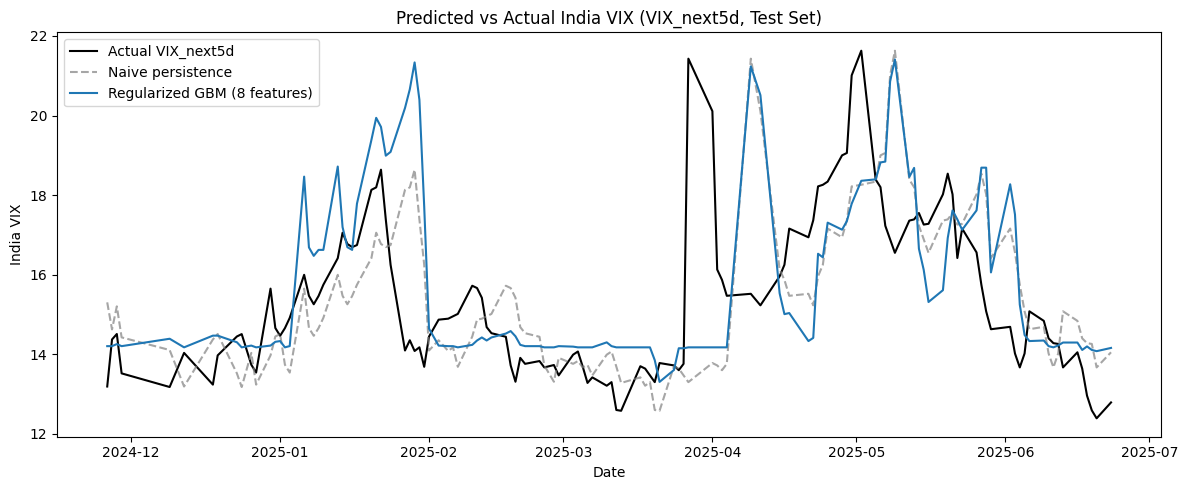

✓ Since VIX is highly persistent day-to-day, beating naive persistence
  meaningfully at the 1-day horizon is hard. The 5-day horizon is a
  fairer test of whether the model adds real forecasting value.


In [27]:
# ==========================================
# CELL 8 — VISUALIZE: PREDICTED VS ACTUAL VIX ON TEST SET
# ==========================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_df["Date"], y_test, label=f"Actual {TARGET_COL}", color="black", linewidth=1.5)
ax.plot(test_df["Date"], naive_pred, label="Naive persistence", color="gray", linestyle="--", alpha=0.7)
ax.plot(test_df["Date"], gbr_reg_pred, label="Regularized GBM (8 features)", color="tab:blue")
ax.set_xlabel("Date")
ax.set_ylabel("India VIX")
ax.set_title(f"Predicted vs Actual India VIX ({TARGET_COL}, Test Set)")
ax.legend()
plt.tight_layout()
plt.savefig("vix_prediction_test.png", dpi=100)
plt.show()

print("✓ Since VIX is highly persistent day-to-day, beating naive persistence")
print("  meaningfully at the 1-day horizon is hard. The 5-day horizon is a")
print("  fairer test of whether the model adds real forecasting value.")